# Plant Disease Detection using MobileNetV2 and Grad-CAM

In this project, I am building a deep learning model that can identify plant diseases from leaf images.

I will use transfer learning with MobileNetV2, which is already trained on ImageNet. The model will be adapted to classify the plant disease classes available in my dataset.

Along with the prediction, I will also use Grad-CAM to understand which parts of the leaf influenced the model's decision.

The final trained model will later be connected to a separate Flask backend and a separate frontend application.

## 1. Import the required libraries

First, I will import the libraries needed for loading the dataset, building and training the model, evaluating its performance, and generating visual explanations.

In [3]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully!
TensorFlow version: 2.21.0


## 2. Set up the dataset path

The dataset is stored in the `dataset` folder at the root of the project.

Since this notebook is inside the `notebook` folder, I will use a relative path to access the dataset.

In [4]:
DATASET_PATH = "../dataset"

print("Dataset path:", os.path.abspath(DATASET_PATH))
print("Dataset folder exists:", os.path.exists(DATASET_PATH))

Dataset path: c:\Plant Diseas detection\dataset
Dataset folder exists: True


## 3. Check the dataset structure

Before loading the images, I will check the folders available inside the dataset.

Each class will be represented by a separate folder, so this also helps me confirm that the dataset is organized correctly.

In [5]:
class_folders = sorted([
    folder
    for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
])

print("Number of folders found:", len(class_folders))
print("\nFolders:")

for i, folder in enumerate(class_folders):
    print(f"{i}: {folder}")

Number of folders found: 16

Folders:
0: Pepper__bell___Bacterial_spot
1: Pepper__bell___healthy
2: PlantVillage
3: Potato___Early_blight
4: Potato___Late_blight
5: Potato___healthy
6: Tomato_Bacterial_spot
7: Tomato_Early_blight
8: Tomato_Late_blight
9: Tomato_Leaf_Mold
10: Tomato_Septoria_leaf_spot
11: Tomato_Spider_mites_Two_spotted_spider_mite
12: Tomato__Target_Spot
13: Tomato__Tomato_YellowLeaf__Curl_Virus
14: Tomato__Tomato_mosaic_virus
15: Tomato_healthy


## 4. Prepare the class names

I will use the dataset folder names as the class names for the model.

Keeping these names in the same order throughout the project is important because the model's output index must always map to the correct disease class.

In [6]:
class_names = class_folders

print("Total classes:", len(class_names))
print("\nClass names:")

for index, class_name in enumerate(class_names):
    print(f"{index}: {class_name}")

Total classes: 16

Class names:
0: Pepper__bell___Bacterial_spot
1: Pepper__bell___healthy
2: PlantVillage
3: Potato___Early_blight
4: Potato___Late_blight
5: Potato___healthy
6: Tomato_Bacterial_spot
7: Tomato_Early_blight
8: Tomato_Late_blight
9: Tomato_Leaf_Mold
10: Tomato_Septoria_leaf_spot
11: Tomato_Spider_mites_Two_spotted_spider_mite
12: Tomato__Target_Spot
13: Tomato__Tomato_YellowLeaf__Curl_Virus
14: Tomato__Tomato_mosaic_virus
15: Tomato_healthy


## 5. Load the image dataset

I will load the leaf images directly from the class folders.

The images will be resized to 224 × 224 pixels because this is the input size used by MobileNetV2. I will also keep a small portion of the data aside for validation so that I can evaluate how well the model performs on images it has not seen during training.

In [11]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("Dataset loaded successfully!")
print("Number of classes:", len(train_ds.class_names))
print("Training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
Dataset loaded successfully!
Number of classes: 15
Training batches: 516
Validation batches: 129


## 6. Visualize sample images

Before training the model, I will display a few sample images from the training dataset.

This helps me verify that the images are loaded correctly and that the corresponding disease labels are being assigned properly.

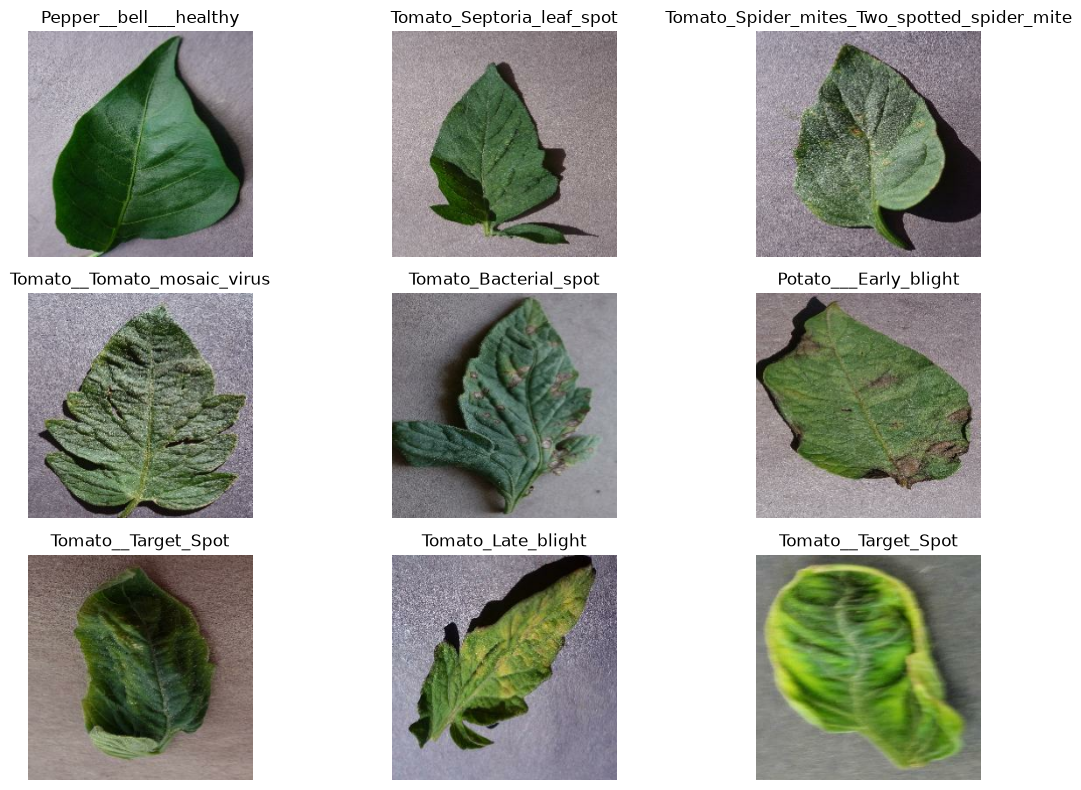

In [12]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

plt.tight_layout()
plt.show()

## 7. Analyze the class distribution

Before training the model, I will check how many images are available in each disease class.

This helps me understand whether the dataset is balanced or if some classes contain significantly more images than others.

In [14]:
class_folders = sorted([
    folder
    for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
])

class_names = class_folders

print("Total classes:", len(class_names))
print("\nClass names:")

for index, class_name in enumerate(class_names):
    print(f"{index}: {class_name}")

Total classes: 15

Class names:
0: Pepper__bell___Bacterial_spot
1: Pepper__bell___healthy
2: Potato___Early_blight
3: Potato___Late_blight
4: Potato___healthy
5: Tomato_Bacterial_spot
6: Tomato_Early_blight
7: Tomato_Late_blight
8: Tomato_Leaf_Mold
9: Tomato_Septoria_leaf_spot
10: Tomato_Spider_mites_Two_spotted_spider_mite
11: Tomato__Target_Spot
12: Tomato__Tomato_YellowLeaf__Curl_Virus
13: Tomato__Tomato_mosaic_virus
14: Tomato_healthy


In [15]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(DATASET_PATH, class_name)
    image_count = len([
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ])
    class_counts[class_name] = image_count

print("Number of images in each class:\n")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Number of images in each class:

Pepper__bell___Bacterial_spot: 997
Pepper__bell___healthy: 1478
Potato___Early_blight: 1000
Potato___Late_blight: 1000
Potato___healthy: 152
Tomato_Bacterial_spot: 2127
Tomato_Early_blight: 1000
Tomato_Late_blight: 1909
Tomato_Leaf_Mold: 952
Tomato_Septoria_leaf_spot: 1771
Tomato_Spider_mites_Two_spotted_spider_mite: 1676
Tomato__Target_Spot: 1404
Tomato__Tomato_YellowLeaf__Curl_Virus: 3208
Tomato__Tomato_mosaic_virus: 373
Tomato_healthy: 1591


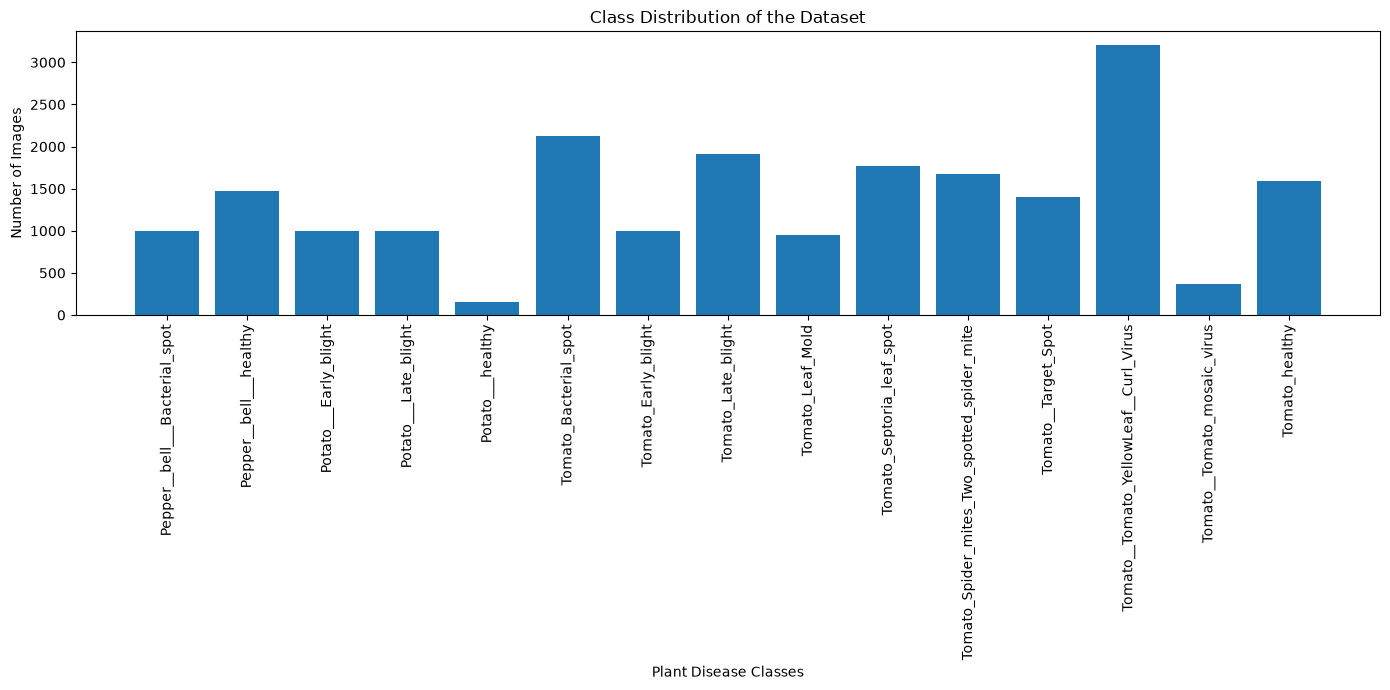

In [16]:
plt.figure(figsize=(14, 7))

plt.bar(class_counts.keys(), class_counts.values())

plt.xlabel("Plant Disease Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution of the Dataset")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 8. Apply data augmentation

To improve the model's ability to generalize to new images, I will apply data augmentation to the training dataset.

Data augmentation creates modified versions of the training images by applying transformations such as random flipping, rotation, zooming, and contrast adjustment.

These transformations help the model learn useful features from different variations of the same plant leaf image.

In [17]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomContrast(0.1)
])

print("Data augmentation pipeline created successfully.")

Data augmentation pipeline created successfully.


## 9. Visualize data augmentation

I will visualize the effect of the data augmentation pipeline on sample training images.

This helps verify that the augmentation techniques are producing reasonable variations of the original plant leaf images before training the model.

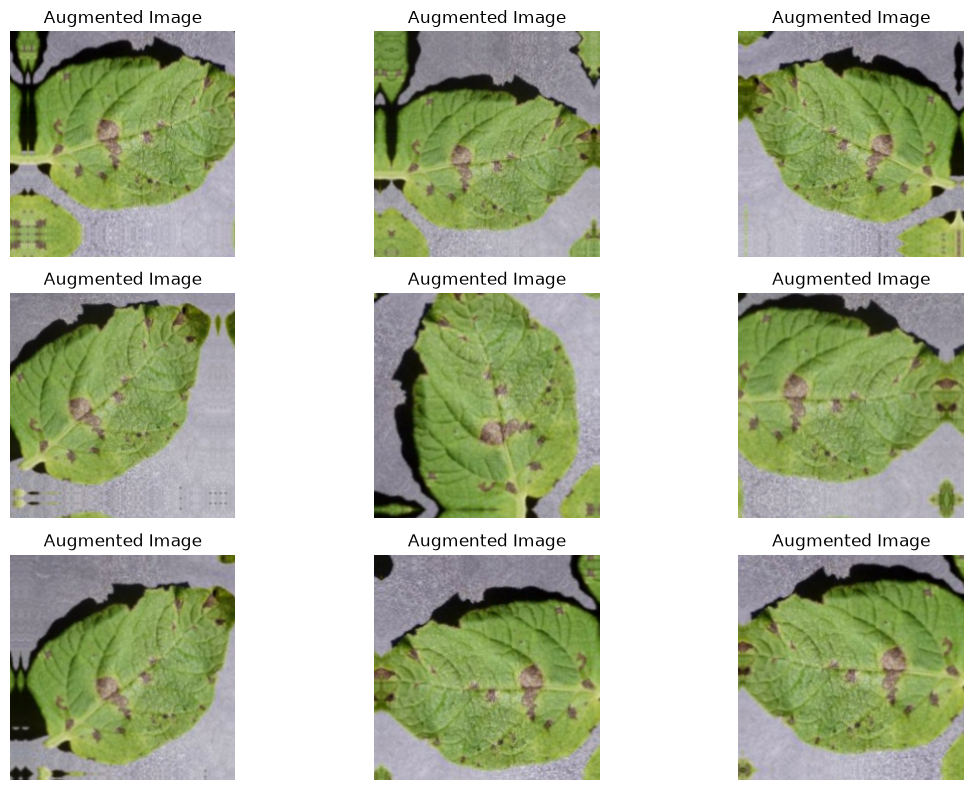

In [18]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):

    original_image = images[0]

    for i in range(9):

        augmented_image = data_augmentation(
            tf.expand_dims(original_image, axis=0),
            training=True
        )[0]

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            tf.cast(
                tf.clip_by_value(augmented_image, 0, 255),
                tf.uint8
            )
        )

        plt.title("Augmented Image")
        plt.axis("off")

plt.tight_layout()
plt.show()

## 10. Optimize dataset loading

To improve the training performance, I will optimize the dataset pipeline using caching and prefetching.

Caching helps keep the dataset available in memory after the first iteration, while prefetching allows the input pipeline to prepare the next batch while the model is processing the current batch.

In [19]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print("Dataset pipeline optimized.")

Dataset pipeline optimized.


## 11. Load MobileNetV2

I will use MobileNetV2 as the pretrained base model.

The model is pretrained on ImageNet and will be used with transfer learning for plant disease classification.

The pretrained layers will initially be frozen so that their learned features are not changed during the initial training.

In [20]:
from tensorflow.keras.applications import MobileNetV2

# Load pretrained MobileNetV2
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers
base_model.trainable = False

print("MobileNetV2 loaded successfully!")
print("Total layers:", len(base_model.layers))
print("Trainable:", base_model.trainable)

MobileNetV2 loaded successfully!
Total layers: 154
Trainable: False


## 12. Build Our Classification Model

Now I will build the plant disease classification model using the pretrained MobileNetV2 base model.

The model will use data augmentation, MobileNetV2 preprocessing, feature extraction with Global Average Pooling, dropout, L2 regularization, and a final 15-class softmax classification layer.

In [21]:
from tensorflow.keras import layers, models, regularizers

inputs = layers.Input(shape=(224, 224, 3))

# Day 4: Data Augmentation
x = data_augmentation(inputs)

# MobileNetV2 preprocessing
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

# Day 3: Transfer Learning
x = base_model(x, training=False)

# Feature extraction
x = layers.GlobalAveragePooling2D()(x)

# Day 4: Dropout
x = layers.Dropout(0.30)(x)

# Day 4: L2 Regularization
x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=regularizers.l2(0.001)
)(x)

# Additional Dropout
x = layers.Dropout(0.20)(x)

# 15-class classification
outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = models.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,887 (9.25 MB)

 Trainable params: 165,903 (648.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 13. Compile the Model

Before training, I will compile the model using the Adam optimizer, sparse categorical crossentropy loss, and accuracy as the evaluation metric.

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


## 14. Add Early Stopping

Early stopping will monitor the validation loss during training.

If the validation loss does not improve for 3 consecutive epochs, training will stop and the best model weights will be restored.

In [23]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("Early stopping configured!")

Early stopping configured!


## 15. Train

Now we're finally ready to train.

In [24]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping]
)

Epoch 1/10


c:\Plant Diseas detection\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


516/516 ━━━━━━━━━━━━━━━━━━━━ 452s 849ms/step - accuracy: 0.4627 - loss: 1.9497 - val_accuracy: 0.7330 - val_loss: 1.1624
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 516s 1s/step - accuracy: 0.6799 - loss: 1.2205 - val_accuracy: 0.7962 - val_loss: 0.8896
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 267s 518ms/step - accuracy: 0.7325 - loss: 1.0336 - val_accuracy: 0.8166 - val_loss: 0.7960
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 272s 527ms/step - accuracy: 0.7658 - loss: 0.9159 - val_accuracy: 0.8255 - val_loss: 0.7366
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 276s 535ms/step - accuracy: 0.7809 - loss: 0.8663 - val_accuracy: 0.8423 - val_loss: 0.6792
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 270s 524ms/step - accuracy: 0.7947 - loss: 0.8130 - val_accuracy: 0.8403 - val_loss: 0.6581
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 399s 774ms/step - accuracy: 0.8024 - loss: 0.7719 - val_accuracy: 0.8515 - val_loss: 0.6260
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 792s 2s/step - accuracy: 0.8052 - loss: 0.7594 - v

## 16. Plot Training Performance

### Accuracy

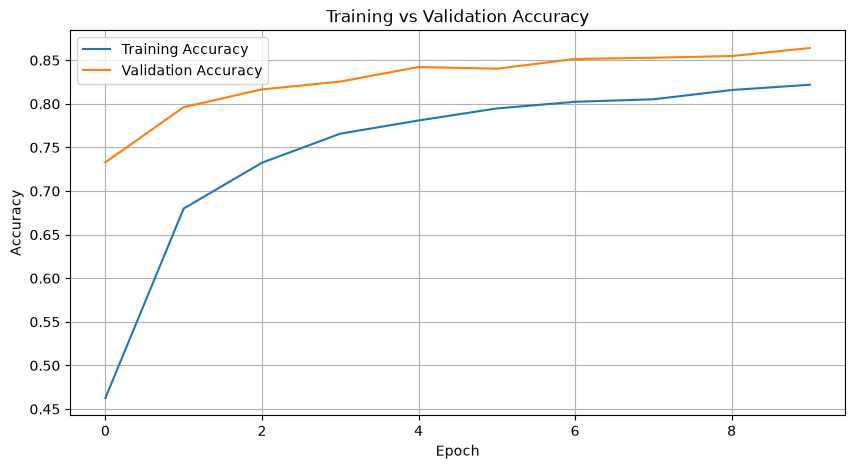

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

### Loss

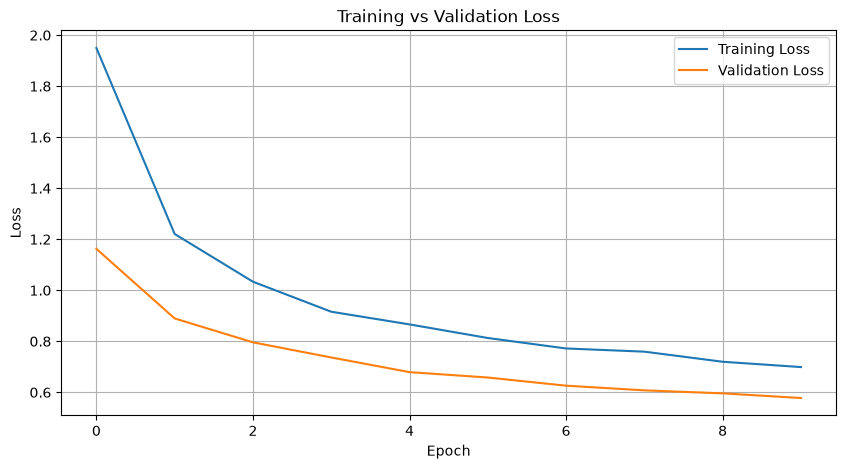

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

## 17. Evaluate the Model

In [27]:
val_loss, val_accuracy = model.evaluate(val_ds, verbose=1)

print("\n==============================")
print("FINAL MODEL PERFORMANCE")
print("==============================")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_accuracy * 100:.2f}%")

129/129 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.8641 - loss: 0.5778

FINAL MODEL PERFORMANCE
Validation Loss     : 0.5778
Validation Accuracy : 86.41%


## 18. Save the Model

The trained model will be saved so that it can later be used by the backend for plant disease prediction.

In [28]:
MODEL_SAVE_PATH = "../backend/model/plant_disease_mobilenetv2.keras"

model.save(MODEL_SAVE_PATH)

print("Model saved successfully!")
print(MODEL_SAVE_PATH)

Model saved successfully!
../backend/model/plant_disease_mobilenetv2.keras


## 19. Generate Predictions

I will generate predictions for the validation dataset and compare the predicted classes with the actual labels.

In [29]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Prediction completed!")
print("Total validation samples:", len(y_true))

Prediction completed!
Total validation samples: 4127


## 20. Classification Report

This is an important placement/interview-level evaluation step.

In [30]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.95      0.93      0.94       200
                     Pepper__bell___healthy       0.95      0.99      0.97       302
                      Potato___Early_blight       0.98      0.94      0.96       189
                       Potato___Late_blight       0.83      0.96      0.89       188
                           Potato___healthy       0.96      0.77      0.86        31
                      Tomato_Bacterial_spot       0.81      0.94      0.87       441
                        Tomato_Early_blight       0.89      0.30      0.45       191
                         Tomato_Late_blight       0.88      0.88      0.88       341
                           Tomato_Leaf_Mold       0.77      0.84      0.80       185
                  Tomato_Septoria_leaf_spot       0.86      0.78      0.82       392
Tomato_Spider_mites_Two_spotted_spider_mite       0.74      0.85

### Precision

Of the images predicted as a particular disease, how many were actually that disease?

### Recall

Of all actual images belonging to a disease, how many did our model correctly detect?

### F1-score

Harmonic mean of precision and recall.

This makes the project much stronger than simply saying:

"My model achieved 86% accuracy."

## 21. Confusion Matrix

Now we'll visualize which diseases the model confuses with each other.

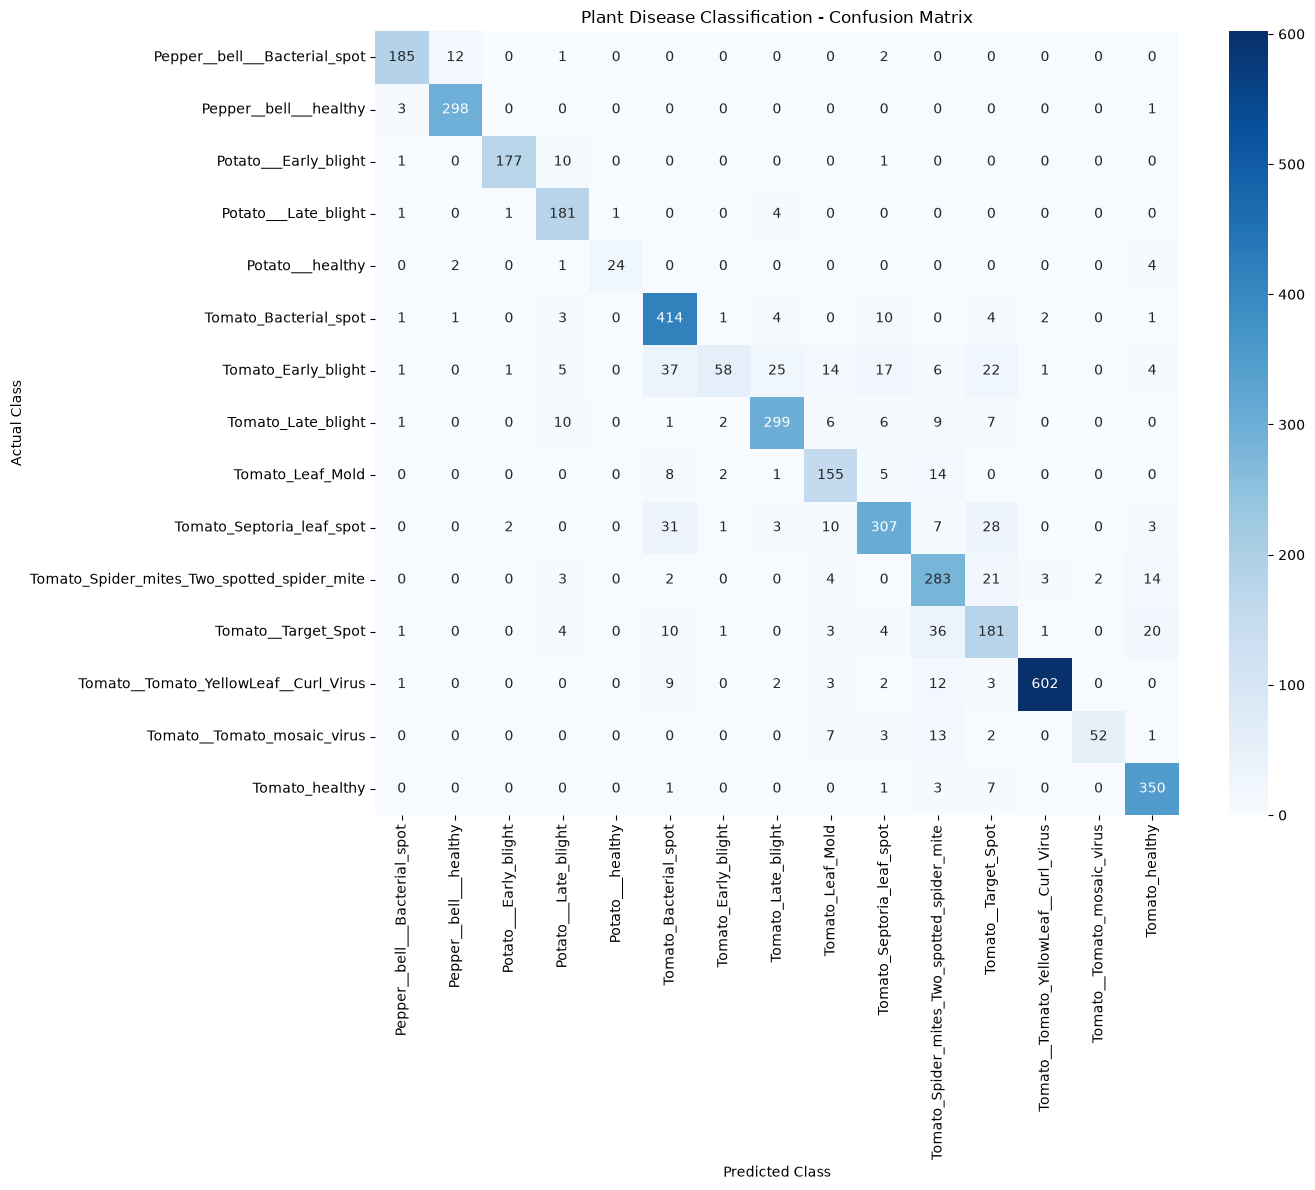

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Plant Disease Classification - Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 22. Test Prediction on One Image

Before Grad-CAM, let's make sure our model predicts an individual image correctly.

In [47]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# Select a random class
random_class = random.choice(class_names)

class_path = os.path.join(
    DATASET_PATH,
    random_class
)

# Select a random image
image_files = [
    f for f in os.listdir(class_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

random_image = random.choice(image_files)

image_path = os.path.join(
    class_path,
    random_image
)

print("Actual Class:", random_class)
print("Image:", random_image)
print("Path:", image_path)

Actual Class: Potato___Early_blight
Image: aa687aac-2f1a-44d8-89aa-3f7d413b4763___RS_Early.B 8055.JPG
Path: ../dataset\Potato___Early_blight\aa687aac-2f1a-44d8-89aa-3f7d413b4763___RS_Early.B 8055.JPG


## 23. Predict the Image

In [48]:
img = tf.keras.utils.load_img(
    image_path,
    target_size=IMG_SIZE
)

img_array = tf.keras.utils.img_to_array(img)

img_batch = tf.expand_dims(img_array, axis=0)

prediction = model.predict(img_batch, verbose=0)

predicted_index = np.argmax(prediction[0])

predicted_class = class_names[predicted_index]

confidence = prediction[0][predicted_index] * 100

print("==============================")
print("PLANT DISEASE PREDICTION")
print("==============================")
print("Actual Class     :", random_class)
print("Predicted Class  :", predicted_class)
print(f"Confidence       : {confidence:.2f}%")

PLANT DISEASE PREDICTION
Actual Class     : Potato___Early_blight
Predicted Class  : Potato___Early_blight
Confidence       : 99.82%


## 24. Display the Image

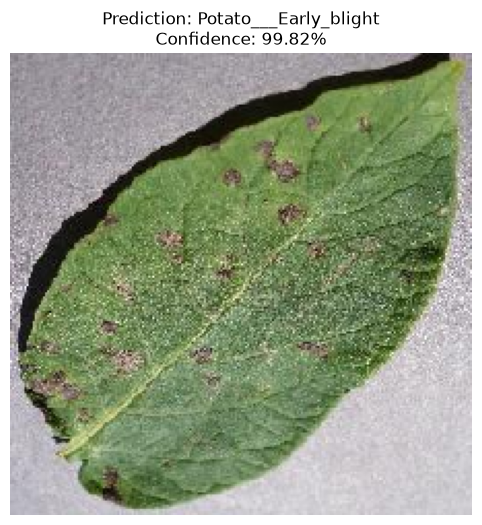

In [49]:
plt.figure(figsize=(6, 6))

plt.imshow(img)

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")
plt.show()

## 25. Find MobileNetV2's Last Convolutional Layer

Now we're going to implement Grad-CAM.

First inspect the MobileNetV2 layers.

In [50]:
# Show our complete model layers

for i, layer in enumerate(model.layers):
    print(
        i,
        "->",
        layer.name,
        "->",
        layer.__class__.__name__
    )

0 -> input_layer_2 -> InputLayer
1 -> sequential -> Sequential
2 -> mobilenetv2_1.00_224 -> Functional
3 -> global_average_pooling2d -> GlobalAveragePooling2D
4 -> dropout -> Dropout
5 -> dense -> Dense
6 -> dropout_1 -> Dropout
7 -> dense_1 -> Dense


## 26. Create Grad-CAM Model

In [51]:
# MobileNetV2 feature extractor
gradcam_base = tf.keras.Model(
    inputs=base_model.input,
    outputs=base_model.get_layer("out_relu").output
)

print("Grad-CAM base model created!")

Grad-CAM base model created!


## 27. Get the trained classification head

Now we'll identify the layers after MobileNetV2.

In [52]:
# Classification head layers

gap_layer = model.get_layer(
    "global_average_pooling2d"
)

dense_layer = model.get_layer(
    "dense"
)

final_layer = model.layers[-1]

print("GAP layer :", gap_layer.name)
print("Dense layer:", dense_layer.name)
print("Final layer:", final_layer.name)

GAP layer : global_average_pooling2d
Dense layer: dense
Final layer: dense_1


## 28. Grad-CAM Function

In [53]:
def generate_gradcam(img_array, predicted_index):

    img_array = tf.cast(img_array, tf.float32)

    # MobileNetV2 preprocessing
    img_preprocessed = tf.keras.applications.mobilenet_v2.preprocess_input(
        img_array
    )

    with tf.GradientTape() as tape:

        # Get MobileNetV2 feature maps
        conv_outputs = gradcam_base(
            img_preprocessed,
            training=False
        )

        # Watch feature maps
        tape.watch(conv_outputs)

        # Classification head
        x = gap_layer(conv_outputs)

        x = dense_layer(x)

        predictions = final_layer(x)

        # Score of predicted class
        class_score = predictions[:, predicted_index]

        # Calculate gradients
        grads = tape.gradient(
            class_score,
            conv_outputs
        )

        # Average gradients
        pooled_grads = tf.reduce_mean(
            grads,
            axis=(1, 2)
        )

        # Remove batch dimension
        conv_outputs = conv_outputs[0]
        pooled_grads = pooled_grads[0]

        # Weighted feature maps
        heatmap = tf.reduce_sum(
            conv_outputs * pooled_grads,
            axis=-1
        )

        # Remove negative values
        heatmap = tf.maximum(
            heatmap,
            0
        )

        # Normalize
        heatmap = heatmap / (
            tf.reduce_max(heatmap)
            + tf.keras.backend.epsilon()
        )

        return heatmap.numpy()

## 29. Generate the Heatmap

In [54]:
heatmap = generate_gradcam(
    img_batch,
    predicted_index
)

print("Grad-CAM generated successfully!")
print("Heatmap shape:", heatmap.shape)

Grad-CAM generated successfully!
Heatmap shape: (7, 7)


## 30. Display Grad-CAM Heatmap

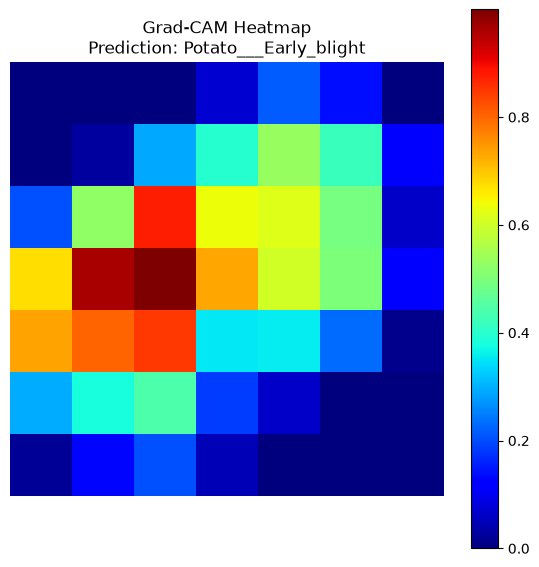

In [55]:
plt.figure(figsize=(7, 7))

plt.imshow(heatmap, cmap="jet")

plt.title(
    f"Grad-CAM Heatmap\n"
    f"Prediction: {predicted_class}"
)

plt.colorbar()
plt.axis("off")

plt.show()

## 31. Overlay Grad-CAM on the Leaf

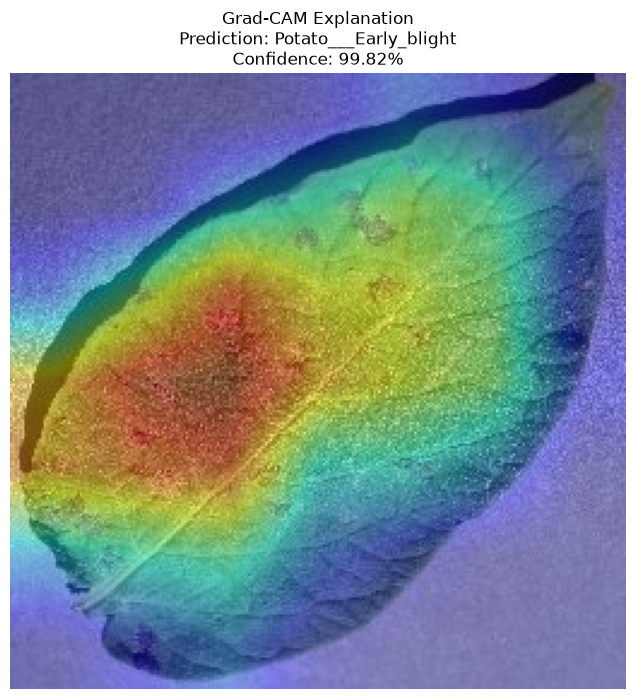

In [56]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read original image
original = cv2.imread(image_path)

# Convert BGR to RGB
original = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)

# Resize Grad-CAM heatmap to original image size
heatmap_resized = cv2.resize(
    heatmap,
    (original.shape[1], original.shape[0])
)

# Convert heatmap to 0-255
heatmap_uint8 = np.uint8(
    255 * heatmap_resized
)

# Apply color map
heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

# Convert BGR to RGB
heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# Overlay heatmap with original image
superimposed = cv2.addWeighted(
    original,
    0.6,
    heatmap_color,
    0.4,
    0
)

# Display
plt.figure(figsize=(8, 8))

plt.imshow(superimposed)

plt.title(
    f"Grad-CAM Explanation\n"
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")
plt.show()

## 32. Better 3-Image Explanation

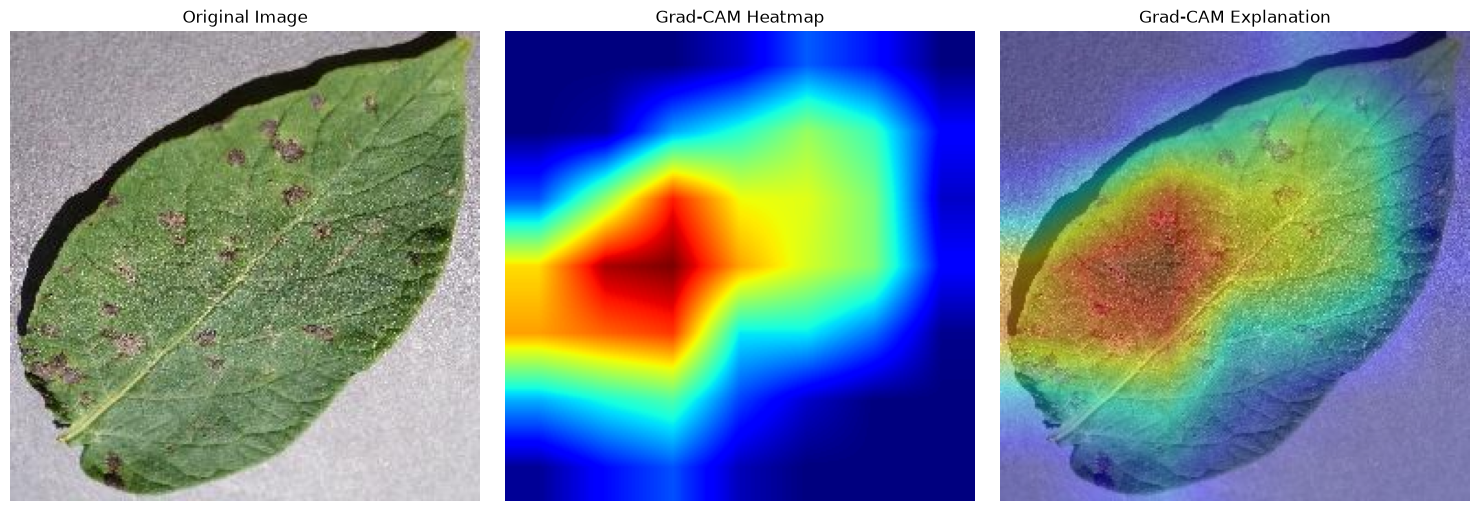

In [57]:
plt.figure(figsize=(15, 5))

# Original
plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")

# Heatmap
plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

# Overlay
plt.subplot(1, 3, 3)
plt.imshow(superimposed)
plt.title("Grad-CAM Explanation")
plt.axis("off")

plt.tight_layout()
plt.show()